In [1]:
# =============================================================================
# 07_bsa_sinphi.ipynb
# Beam Spin Asymmetry — sin φh moment
#
# CORRECTIONS STATUS:
#   Acceptance correction : NOT APPLIED (cancels in N+/N- ratio)
#   Radiative correction  : NOT APPLIED
#   → Results are PRELIMINARY
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.backends.backend_pdf import PdfPages
import glob, os, sys

# ── Load config (only file you need to edit when moving to a new machine) ─────
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')),
                                'scripts'))
from config import PARQUET_DIR, YIELDS_DIR, SCRIPTS_DIR, P_BEAM, TARGET, POLARITY, data_file
sys.path.insert(0, SCRIPTS_DIR)
from analysis_cuts import apply_sidis_cuts

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_FILE = data_file()   # edit TARGET/POLARITY/suffix in config.py

# ── Phi bins (degrees) ────────────────────────────────────────────────────────
PHI_BINS = np.linspace(0, 360, 7)   # 6 bins of 60° each

# ── Load and apply SIDIS cuts ─────────────────────────────────────────────────
data_raw = pd.read_parquet(DATA_FILE)
data     = apply_sidis_cuts(data_raw[data_raw['w_pip'] == 1])

print(f'Events after SIDIS cuts: {len(data)}')
print(f'Helicity values: {data["helicity"].value_counts().to_dict() if "helicity" in data.columns else "NO HELICITY"}')
print(f'P_BEAM = {P_BEAM}')


In [2]:
import sys
print(sys.executable)

/Users/sumanshrestha/myenv/bin/python


In [3]:
# =============================================================================
# KINEMATIC BINS
# Change these to select any (Q², xB, zh, pT²) bin
# =============================================================================

# zh bins for the main plot
ZH_BINS  = [0.3, 0.4, 0.5, 0.6, 0.7]

# Optional Q², xB filter — set to None to use all events
Q2_RANGE = (1.5, 3.0)   # (lo, hi) or None
XB_RANGE = (0.15, 0.3)  # (lo, hi) or None

# Apply optional Q², xB filter
df = data.copy()
if Q2_RANGE:
    df = df[(df['Q2'] >= Q2_RANGE[0]) & (df['Q2'] < Q2_RANGE[1])]
    print(f'After Q2 in {Q2_RANGE}: {len(df)} events')
if XB_RANGE:
    df = df[(df['xB'] >= XB_RANGE[0]) & (df['xB'] < XB_RANGE[1])]
    print(f'After xB in {XB_RANGE}: {len(df)} events')

# Split by helicity
df_plus  = df[df['helicity'] ==  1]
df_minus = df[df['helicity'] == -1]
print(f'N+ = {len(df_plus)},  N- = {len(df_minus)}')

After Q2 in (1.5, 3.0): 2523 events
After xB in (0.15, 0.3): 1636 events
N+ = 834,  N- = 778


In [4]:
# =============================================================================
# FIT FUNCTION
# =============================================================================
# Per phi bin:
#   n+(phi) = N+(phi) / N+_total   (luminosity-normalized yield)
#   n-(phi) = N-(phi) / N-_total
#   A_LU(phi) = (n+ - n-) / (n+ + n-) / P_beam
#
# Fit: A_LU(phi) = A_LU^sinphi * sin(phi)
# =============================================================================

def bsa_model(phi_rad, a1):
    """A_LU(phi) = A_LU^sinphi * sin(phi)"""
    return a1 * np.sin(phi_rad)


def compute_bsa(df_plus, df_minus, phi_bins=PHI_BINS):
    phi_centres = (phi_bins[:-1] + phi_bins[1:]) / 2.0
    phi_rad     = np.deg2rad(phi_centres)

    N_plus_tot  = float(len(df_plus))
    N_minus_tot = float(len(df_minus))

    N_plus  = np.histogram(df_plus['phi_h'],  bins=phi_bins)[0].astype(float)
    N_minus = np.histogram(df_minus['phi_h'], bins=phi_bins)[0].astype(float)

    # luminosity-normalize each bin
    n_plus  = N_plus  / N_plus_tot
    n_minus = N_minus / N_minus_tot
    n_tot   = n_plus + n_minus

    mask = (N_plus > 0) & (N_minus > 0)
    print(f'phi bins with both helicities: {mask.sum()}/{len(mask)}')
    print(f'N+: {N_plus}  N-: {N_minus}')

    if mask.sum() < 3:
        print('Not enough bins'); return None

    A_raw  = (n_plus[mask] - n_minus[mask]) / n_tot[mask]
    # error propagation for normalized ratio
    dA_raw = (2.0 / n_tot[mask]**2) * np.sqrt(
        (n_minus[mask] / N_plus_tot  * np.sqrt(N_plus[mask]))**2 +
        (n_plus[mask]  / N_minus_tot * np.sqrt(N_minus[mask]))**2
    )
    A_lu  = A_raw  / P_BEAM
    dA_lu = dA_raw / P_BEAM

    try:
        popt, pcov = curve_fit(bsa_model, phi_rad[mask], A_lu,
                               sigma=dA_lu, absolute_sigma=True,
                               p0=[0.], maxfev=10000)
        perr = np.sqrt(np.diag(pcov))
        return dict(phi_deg=phi_centres[mask], phi_rad=phi_rad[mask],
                    A_lu=A_lu, dA_lu=dA_lu,
                    a1=popt[0], da1=perr[0])
    except RuntimeError:
        print('Fit failed'); return None


In [5]:
# =============================================================================
# PLOT 1: A_LU(phi) with sin(phi) fit — selected Q2, xB bin
# =============================================================================

result = compute_bsa(df_plus, df_minus)

if result is None:
    print('Not enough events for fit')
else:
    phi_fit = np.linspace(0, 2*np.pi, 200)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(result['phi_deg'], result['A_lu'], yerr=result['dA_lu'],
                fmt='ko', capsize=3, label='Data')
    ax.plot(np.rad2deg(phi_fit), bsa_model(phi_fit, result['a1']),
            'r-', lw=2,
            label=rf"$A_{{LU}}^{{\sin\phi}}$ = {result['a1']:.4f} $\pm$ {result['da1']:.4f}")
    ax.axhline(0, color='gray', ls='--', lw=1)
    ax.set_xlabel(r'$\phi_h$ (deg)', fontsize=13)
    ax.set_ylabel(r'$A_{LU}(\phi_h)$', fontsize=13)
    ax.set_ylim(-0.2, 0.2)
    title = r'BSA $A_{LU}(\phi_h)$ — LD2 (preliminary, no AC)'
    if Q2_RANGE: title += f'\n$Q^2 \\in {Q2_RANGE}$ GeV\u00b2'
    if XB_RANGE: title += f',  $x_B \\in {XB_RANGE}$'
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 360)
    ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
    plt.tight_layout()
    plt.show()
    print(f"A_LU^sinphi = {result['a1']:+.4f} +/- {result['da1']:.4f}")


phi bins with both helicities: 6/6
N+: [100.  64.  14.   9.  60. 113.]  N-: [ 99.  51.  13.  13.  54. 111.]
phi bins with both helicities: 5/6
N+: [72. 43.  3.  3. 38. 65.]  N-: [60. 37.  0.  3. 34. 59.]
phi bins with both helicities: 6/6
N+: [37. 31.  3.  3. 30. 49.]  N-: [42. 32.  1.  1. 23. 38.]
phi bins with both helicities: 6/6
N+: [29. 20.  1.  2. 15. 30.]  N-: [35. 19.  1.  2. 21. 29.]


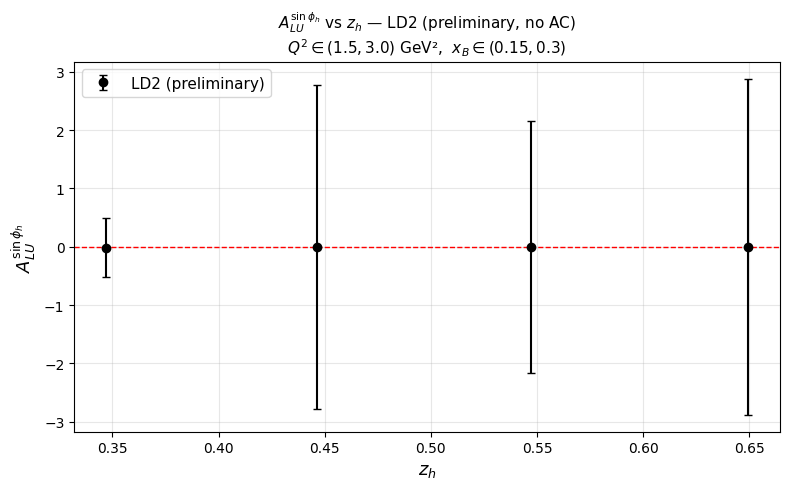

A_LU^sinφ per zh bin:
  zh=[0.3,0.4]  a1=-0.0202 ± 0.5049
  zh=[0.4,0.5]  a1=+0.0006 ± 2.7790
  zh=[0.5,0.6]  a1=-0.0001 ± 2.1584
  zh=[0.6,0.7]  a1=-0.0001 ± 2.8821


In [ ]:
# =============================================================================
# PLOT 2: A_LU^sinφ vs zh  (integrated over Q², xB range set above)
# =============================================================================

results_zh = []
for i in range(len(ZH_BINS) - 1):
    zh_lo, zh_hi = ZH_BINS[i], ZH_BINS[i+1]
    mask_zh = (df['zh'] >= zh_lo) & (df['zh'] < zh_hi)
    res = compute_bsa(df_plus[mask_zh[df_plus.index]], df_minus[mask_zh[df_minus.index]])
    if res:
        res['zh_mean'] = df.loc[mask_zh, 'zh'].mean()
        res['zh_lo']   = zh_lo
        res['zh_hi']   = zh_hi
        results_zh.append(res)

if not results_zh:
    print('No zh bins with enough events — check helicity columns')
else:
    zh_vals  = [r['zh_mean'] for r in results_zh]
    a1_vals  = [r['a1']      for r in results_zh]
    da1_vals = [r['da1']     for r in results_zh]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(zh_vals, a1_vals, yerr=da1_vals,
                fmt='ko', capsize=3, label='LD2 (preliminary)')
    ax.axhline(0, color='red', ls='--', lw=1)
    ax.set_xlabel(r'$z_h$', fontsize=13)
    ax.set_ylabel(r'$A_{LU}^{\sin\phi_h}$', fontsize=13)
    title = r'$A_{LU}^{\sin\phi_h}$ vs $z_h$ — LD2 (preliminary, no AC)'
    if Q2_RANGE: title += f'\n$Q^2 \\in {Q2_RANGE}$ GeV²'
    if XB_RANGE: title += f',  $x_B \\in {XB_RANGE}$'
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('A_LU^sinφ per zh bin:')
    for r in results_zh:
        print(f"  zh=[{r['zh_lo']:.1f},{r['zh_hi']:.1f}]  a1={r['a1']:+.4f} ± {r['da1']:.4f}")